In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/icu_data.csv')

print("✅ Data Loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

✅ Data Loaded!
Shape: (91713, 85)

Columns:
['encounter_id', 'patient_id', 'hospital_id', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache', 'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'ventilated_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_diasbp_min', 'h1_diasbp_noninvasive_max', 'h1_diasbp_noninva

In [2]:
print("=== DATASET INFO ===")
print(df.info())

print("\n=== FIRST 5 ROWS ===")
df.head()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 85 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   encounter_id                   91713 non-null  int64  
 1   patient_id                     91713 non-null  int64  
 2   hospital_id                    91713 non-null  int64  
 3   age                            87485 non-null  float64
 4   bmi                            88284 non-null  float64
 5   elective_surgery               91713 non-null  int64  
 6   ethnicity                      90318 non-null  object 
 7   gender                         91688 non-null  object 
 8   height                         90379 non-null  float64
 9   icu_admit_source               91601 non-null  object 
 10  icu_id                         91713 non-null  int64  
 11  icu_stay_type                  91713 non-null  object 
 12  icu_type                 

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("=== MISSING VALUES (Top 20) ===")
print(missing_df[missing_df['Missing Count'] > 0].head(20))

=== MISSING VALUES (Top 20) ===
                               Missing Count  Percentage
Unnamed: 83                            91713  100.000000
d1_potassium_max                        9585   10.451081
d1_potassium_min                        9585   10.451081
h1_mbp_noninvasive_min                  9084    9.904812
h1_mbp_noninvasive_max                  9084    9.904812
apache_4a_hospital_death_prob           7947    8.665075
apache_4a_icu_death_prob                7947    8.665075
h1_diasbp_noninvasive_max               7350    8.014131
h1_diasbp_noninvasive_min               7350    8.014131
h1_sysbp_noninvasive_max                7341    8.004318
h1_sysbp_noninvasive_min                7341    8.004318
d1_glucose_max                          5807    6.331709
d1_glucose_min                          5807    6.331709
h1_mbp_min                              4639    5.058171
h1_mbp_max                              4639    5.058171
h1_resprate_min                         4357    4.750690

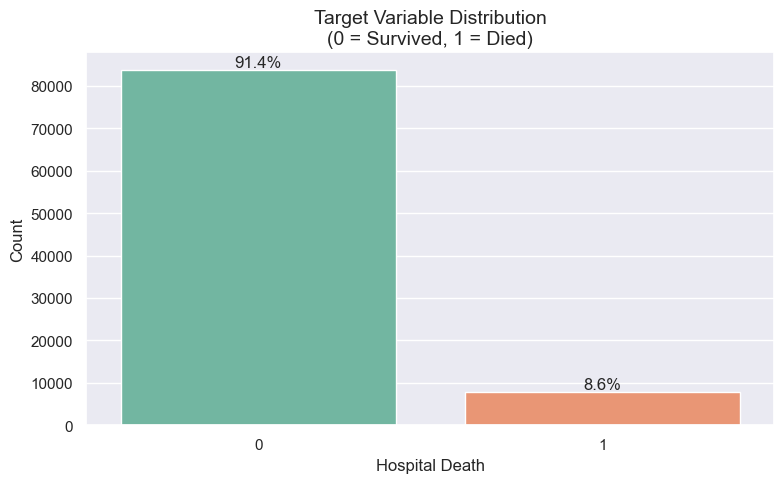

hospital_death
0    83798
1     7915
Name: count, dtype: int64


In [4]:
target = 'hospital_death'

plt.figure(figsize=(8, 5))
ax = sns.countplot(x=target, data=df, palette='Set2')
plt.title('Target Variable Distribution\n(0 = Survived, 1 = Died)', fontsize=14)
plt.xlabel('Hospital Death')
plt.ylabel('Count')

# Percentage labels
total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

print(df[target].value_counts())

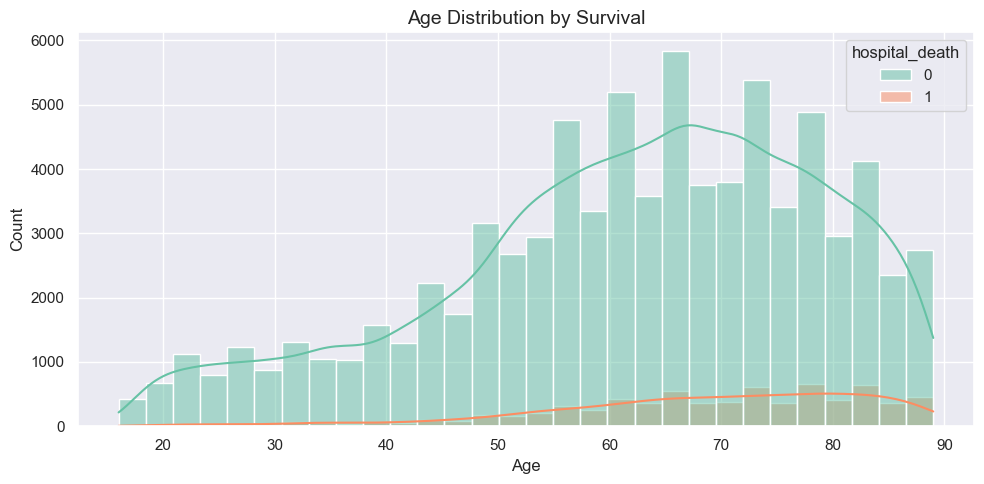

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='hospital_death', 
             bins=30, palette='Set2', kde=True)
plt.title('Age Distribution by Survival', fontsize=14)
plt.xlabel('Age')
plt.tight_layout()
plt.show()

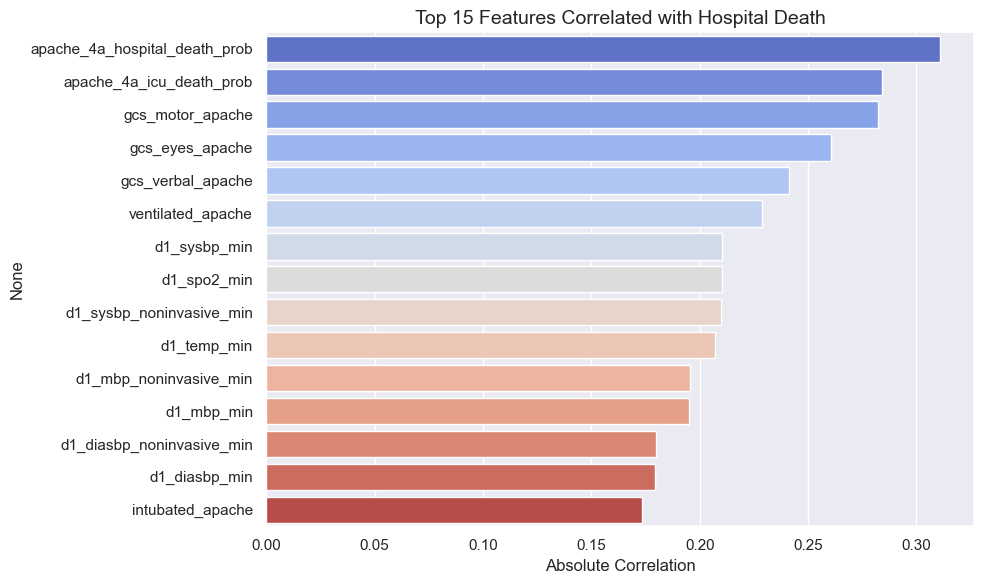

In [6]:
# Top numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
top_corr = df[numeric_cols].corr()['hospital_death'].abs().sort_values(ascending=False)[1:16]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Top 15 Features Correlated with Hospital Death', fontsize=14)
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()